In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D
import itertools
import math

SIZE = 10
DEGREE = 2
EPISODES = 10000
STEP_SIZE_0 = 1*(10**-1)
STEP_SIZE_1 = 5*(10**-6)
DISCOUNT = .5
SHOW_EPISODE = 100


def main():
    epsilon = 1
    average = 0
    step_size = STEP_SIZE_0
    weights = np.full((DEGREE+1,)*6, 0.0)
    store_avg = []

    for current in range(EPISODES):
        pos = (np.random.choice([0,1])*(SIZE-1),np.random.choice([0,1])*(SIZE-1))
        goal = (np.random.randint(3,SIZE-3),np.random.randint(3,SIZE-3))
        if(goal[1]==pos[1]):
            goal = (goal[0],goal[1]+1)
        dist = np.subtract(goal,pos)
        count = 0

        while((dist[0]!=0)and(dist[1]!=0)):

            a = pick_action(pos,goal,epsilon,weights)
            action = (round(math.cos(a)),round(math.sin(a)))
            new_pos = find_new(action,pos)
            new_dist = np.subtract(goal,new_pos)

            features = calc_features(pos,goal,dist)
            next_features = calc_features(new_pos,goal,new_dist)
            reward = find_reward(new_pos,goal)

            old_value = np.sum(np.multiply(weights,features))
            new_value = np.sum(np.multiply(weights,next_features))

            weights = np.add(weights,step_size*(reward+DISCOUNT*new_value-old_value)*features)

            pos = new_pos
            dist = new_dist
            count += 1

        if((current+1)%SHOW_EPISODE==0):
            store_avg.append(average)
            show_current(weights,goal,current,average,store_avg)
            average = 0
        else:
            average = (average*(current%SHOW_EPISODE)+count)/((current+1)%SHOW_EPISODE)
        epsilon = epsilon - epsilon/(EPISODES//2-1)
        step_size = STEP_SIZE_0/(1+((STEP_SIZE_0-STEP_SIZE_1)/(STEP_SIZE_1*EPISODES))*current)


def show_current(weights,goal,current,average,store_avg):
    print('Episode: '+str(current+1)+'\nAverage: '+str(average)+'\nGoal: '+str(goal),end='\n\n')
    x,y = np.meshgrid(np.arange(SIZE),np.arange(SIZE))
    z = np.zeros((SIZE,SIZE))
    for i in range(SIZE):
        for j in range(SIZE):
            z[i][j] = find_value((i,j),goal,np.subtract(goal,(i,j)),weights)
    fig = plt.figure(figsize=(10,3.5))
    gs = GridSpec(1, 2, width_ratios=[2, 1])
    ax1 = fig.add_subplot(gs[0], projection="3d")
    ax1.plot_surface(x,y,z)
    ax1.set_title('Value Function')
    ax2 = fig.add_subplot(gs[1])
    ax2.plot(SHOW_EPISODE*np.arange(len(store_avg)),np.array(store_avg),color='red')
    ax2.set_title('Running Average')
    plt.ylim([0,1.2*max(store_avg)])
    #plt.xlim([0,EPISODES//SHOW_EPISODE])
    plt.subplots_adjust(wspace=-.1)
    plt.show()
    print_episode(weights,goal)

def calc_features(pos,goal,dist):
    indices = np.indices((DEGREE+1,)*6)
    start_x, start_y, end_x, end_y, x_dist, y_dist = [indices[i].flatten() for i in range(6)]
    temp = (
        ((pos[0]/SIZE)**start_x)*((pos[1]/SIZE)**start_y)*
        ((goal[0]/SIZE)**end_x)*((goal[1]/SIZE)**end_y)*
        ((dist[0]/SIZE)**x_dist)*((dist[1]/SIZE)**y_dist)
    )
    temp = temp.reshape((DEGREE+1,)*6)
    return(temp)

def pick_action(pos,goal,epsilon,weights):
    if(np.random.random()<epsilon):
        return(np.random.choice([0,np.pi/2,np.pi,3*np.pi/2]))
    else:
        return((np.pi/2)*arg_max(pos,goal,weights))

def arg_max(pos,goal,weights):
    values = np.zeros(4)
    for i in range(4):
        new_pos = (pos[0]+round(math.cos(np.pi/2*i)),pos[1]+round(math.sin(np.pi/2*i)))
        if((new_pos[0]>=0) and (new_pos[0]<=SIZE-1) and (new_pos[1]>=0) and (new_pos[1]<=SIZE-1)):
            values[i] = find_value(new_pos,goal,np.subtract(goal,new_pos),weights)
        else:
            values[i] = -math.inf
    return(np.argmax(values))

def find_value(pos,goal,dist,weights):
    flat_w = weights.flatten()
    indices = np.indices((DEGREE+1,)*6)
    start_x, start_y, end_x, end_y, x_dist, y_dist = [indices[i].flatten() for i in range(6)]
    values = flat_w*(
        ((pos[0]/SIZE)**start_x)*((pos[1]/SIZE)**start_y)*
        ((goal[0]/SIZE)**end_x)*((goal[1]/SIZE)**end_y)*
        ((dist[0]/SIZE)**x_dist)*((dist[1]/SIZE)**y_dist)
    )
    return values.sum()

def find_new(action,pos):
    temp1 = min(SIZE-1,max(0,action[0]+pos[0]))
    temp2 = min(SIZE-1,max(0,action[1]+pos[1]))
    return(temp1,temp2)

def find_reward(pos,goal):
    if(pos==goal):
        return 1
    else:
        return(-1/SIZE)

def print_episode(weights,goal):
    sym = {0: ">", 1: "V", 2: "<", 3: "^"}
    for y in range(SIZE):
        line = ' '.join(sym[arg_max((x,y),goal,weights)] for x in range(SIZE))
        print(line)
    print('\n')

main()

Output hidden; open in https://colab.research.google.com to view.

Episode: 50
Average: 176.89795918367346
Goal: (8, 6)



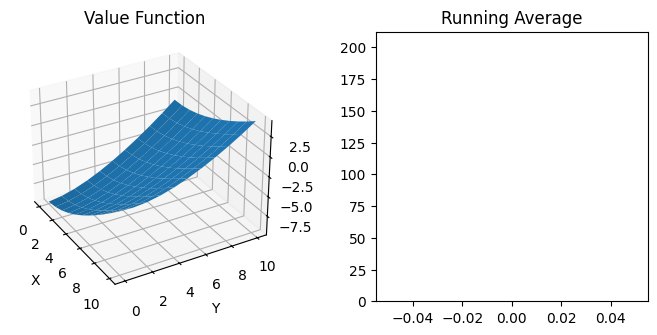

> > > > V   > > > > V 
V > > > V   > > > > V 
V V > > > > > > > > V 
V V V > V   > > > > V 
> > V > ^   > > > > ^ 
    V           >     
V V V V V   > > O > V 
V V V V V   > > > > V 
V V V V V V > > > > V 
V V V V V   V > > > V 
> > > > <   > > > > ^ 


Episode: 100
Average: 132.12244897959187
Goal: (9, 9)



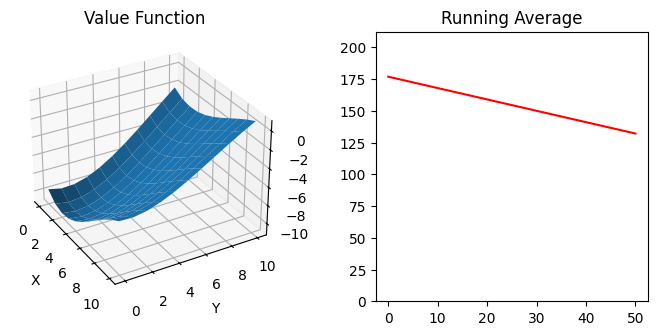

> < > > V   > > > > V 
^ ^ ^ > ^   > > > > ^ 
^ ^ > > > > > > > > ^ 
V V > > V   > > > > V 
> > V > ^   > > > > ^ 
    V           >     
V V V V V   > > > > V 
V V V V V   > > > > V 
V V V V V > > > > > V 
V V V V V   > > > O V 
> > > > <   > > > > ^ 




KeyboardInterrupt: 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D
import itertools
import math

ROOM_SIZE = 5  #Odd
DEGREE = 4
EPISODES = 10000
STEP_SIZE_0 = 1*(10**-1)
STEP_SIZE_1 = 1*(10**-4)
DISCOUNT = .8
SHOW_EPISODE = 50
SIZE = ROOM_SIZE*2+1


def main():
    epsilon = 1
    average = 0
    step_size = STEP_SIZE_0
    weights = np.full((DEGREE+1,)*6, 0.0)
    store_avg = []

    for current in range(EPISODES):
        pos = (np.random.randint(0,ROOM_SIZE),np.random.randint(0,ROOM_SIZE))
        goal = (np.random.randint(ROOM_SIZE+1,SIZE),np.random.randint(ROOM_SIZE+1,SIZE))
        dist = np.subtract(goal,pos)
        count = 0

        while((dist[0]!=0)and(dist[1]!=0)):

            a = pick_action(pos,goal,epsilon,weights)
            action = (round(math.cos(a)),round(math.sin(a)))
            new_pos = find_new(action,pos)
            new_dist = np.subtract(goal,new_pos)

            features = calc_features(pos,goal,dist)
            next_features = calc_features(new_pos,goal,new_dist)
            reward = find_reward(pos,new_pos,goal)

            old_value = np.sum(np.multiply(weights,features))
            new_value = np.sum(np.multiply(weights,next_features))

            weights = np.add(weights,step_size*(reward+DISCOUNT*new_value-old_value)*features)

            pos = new_pos
            dist = new_dist
            count += 1

        if((current+1)%SHOW_EPISODE==0):
            store_avg.append(average)
            show_current(weights,goal,current,average,store_avg)
            average = 0
        else:
            average = (average*(current%SHOW_EPISODE)+count)/((current+1)%SHOW_EPISODE)
        epsilon = epsilon - epsilon/(EPISODES//2-1)
        step_size = STEP_SIZE_0/(1+((STEP_SIZE_0-STEP_SIZE_1)/(STEP_SIZE_1*EPISODES))*current)


def show_current(weights,goal,current,average,store_avg):
    print('Episode: '+str(current+1)+'\nAverage: '+str(average)+'\nGoal: '+str(goal),end='\n\n')
    x,y = np.meshgrid(np.arange(SIZE),np.arange(SIZE))
    z = np.zeros((SIZE,SIZE))
    for i in range(SIZE):
        for j in range(SIZE):
            z[i][j] = find_value((i,j),goal,np.subtract(goal,(i,j)),weights)
    fig = plt.figure(figsize=(10,3.5))
    gs = GridSpec(1, 2, width_ratios=[2, 1])
    ax1 = fig.add_subplot(gs[0], projection="3d")
    ax1.plot_surface(x,y,z)
    ax1.set_title('Value Function')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.view_init(elev=30, azim=-30)
    ax2 = fig.add_subplot(gs[1])
    ax2.plot(SHOW_EPISODE*np.arange(len(store_avg)),np.array(store_avg),color='red')
    ax2.set_title('Running Average')
    plt.ylim([0,1.2*max(store_avg)])
    #plt.xlim([0,EPISODES//SHOW_EPISODE])
    plt.subplots_adjust(wspace=-.1)
    plt.show()
    print_episode(weights,goal)

def calc_features(pos,goal,dist):
    indices = np.indices((DEGREE+1,)*6)
    start_x, start_y, end_x, end_y, x_dist, y_dist = [indices[i].flatten() for i in range(6)]
    temp = (
        ((pos[0]/SIZE)**start_x)*((pos[1]/SIZE)**start_y)*
        ((goal[0]/SIZE)**end_x)*((goal[1]/SIZE)**end_y)*
        ((dist[0]/SIZE)**x_dist)*((dist[1]/SIZE)**y_dist)
    )
    temp = temp.reshape((DEGREE+1,)*6)
    return(temp)

def pick_action(pos,goal,epsilon,weights):
    if(np.random.random()<epsilon):
        return(np.random.choice([0,np.pi/2,np.pi,3*np.pi/2]))
    else:
        return((np.pi/2)*arg_max(pos,goal,weights))

def arg_max(pos,goal,weights):
    values = np.zeros(4)
    for i in range(4):
        new_pos = find_new((round(math.cos(np.pi/2*i)),round(math.sin(np.pi/2*i))),pos)
        if(new_pos[0]!=pos[0]or new_pos[1]!=pos[1]):
            values[i] = find_value(new_pos,goal,np.subtract(goal,new_pos),weights)
        else:
            values[i] = -math.inf
    return(np.argmax(values))

def find_value(pos,goal,dist,weights):
    flat_w = weights.flatten()
    indices = np.indices((DEGREE+1,)*6)
    start_x, start_y, end_x, end_y, x_dist, y_dist = [indices[i].flatten() for i in range(6)]
    values = flat_w*(
        ((pos[0]/SIZE)**start_x)*((pos[1]/SIZE)**start_y)*
        ((goal[0]/SIZE)**end_x)*((goal[1]/SIZE)**end_y)*
        ((dist[0]/SIZE)**x_dist)*((dist[1]/SIZE)**y_dist)
    )
    return values.sum()

def find_new(action,pos):
    temp1 = min(SIZE-1,max(0,action[0]+pos[0]))
    temp2 = min(SIZE-1,max(0,action[1]+pos[1]))
    if(temp1==ROOM_SIZE and (temp2!=ROOM_SIZE//2 and temp2!=2*ROOM_SIZE-ROOM_SIZE//2)):
        temp1 = pos[0]
    if(temp2==ROOM_SIZE and (temp1!=ROOM_SIZE//2 and temp1!=2*ROOM_SIZE-ROOM_SIZE//2)):
        temp2 = pos[1]
    return(temp1,temp2)

def find_reward(pos,new_pos,goal):
    if(new_pos==goal):
        return 1
    elif(pos==new_pos):
        return(-1/ROOM_SIZE)
    else:
        return(-np.sum([abs(np.subtract(new_pos,goal)[i]) for i in [0,1]])/ROOM_SIZE)

def print_episode(weights,goal):
    sym = {0: ">", 1: "V", 2: "<", 3: "^"}
    for y in range(SIZE):
        for x in range(SIZE):
            if((x,y)==goal):
                print('O',end=' ')
            elif(x==ROOM_SIZE and (y!=ROOM_SIZE//2 and y!=2*ROOM_SIZE-ROOM_SIZE//2)):
                print(' ',end=' ')
            elif(y==ROOM_SIZE and (x!=ROOM_SIZE//2 and x!=2*ROOM_SIZE-ROOM_SIZE//2)):
                print(' ',end=' ')
            else:
                print(sym[arg_max((x,y),goal,weights)],end=' ')
        print()
    print('\n')

main()